In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

2025-12-22 12:20:18.597912: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-22 12:20:18.624673: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766406018.654265   86795 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766406018.666048   86795 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766406018.694489   86795 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2)

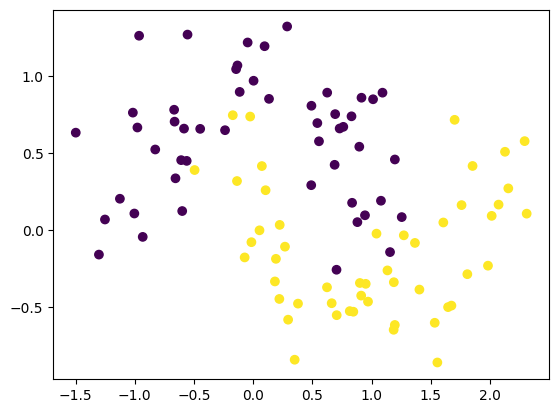

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [4]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

/home/subhamoy/miniforge3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1766406054.693233   86795 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1328 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

I0000 00:00:1766406064.901243   86859 service.cc:152] XLA service 0x7cf54c003730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766406064.901281   86859 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-12-22 12:21:04.924806: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1766406065.075906   86859 cuda_dnn.cc:529] Loaded cuDNN version 91301
2025-12-22 12:21:05.493688: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_127', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1766406067.265830   86859 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-12-22 12:21:09.212714: I external

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


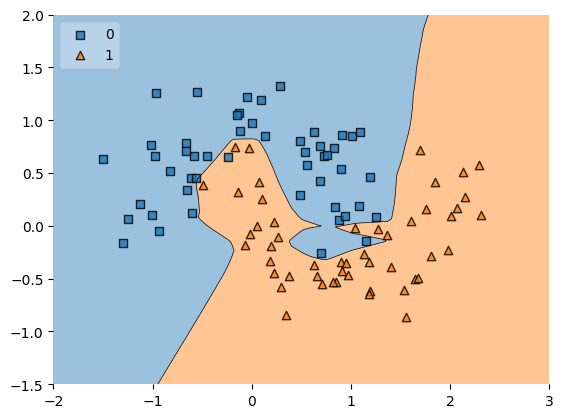

In [6]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

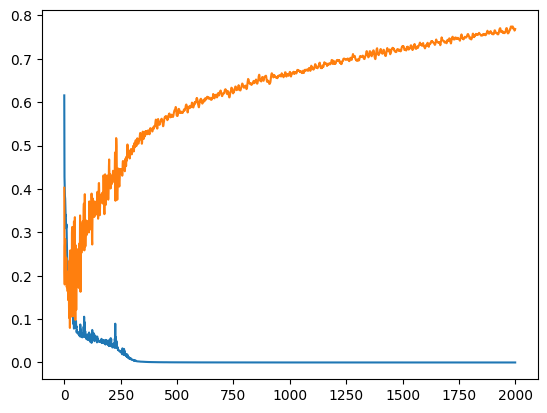

In [7]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

## Regularization

In [17]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu" , kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)))
model2.add(Dense(128, activation="relu" , kernel_regularizer=tensorflow.keras.regularizers.l2(0.01)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

/home/subhamoy/miniforge3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


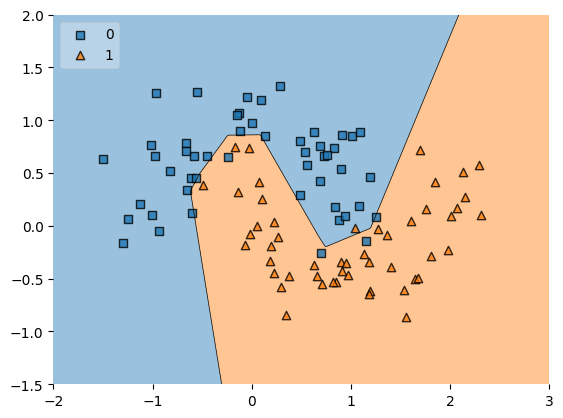

In [19]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

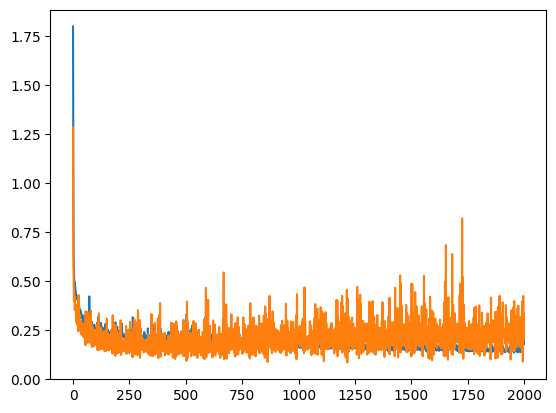

In [20]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [21]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

In [22]:
model1_weight_layer1

array([-0.51874053,  0.08007777,  0.1845738 ,  0.26588517,  0.29883122,
        0.11882137, -0.1796762 , -0.19647412, -0.06772839, -0.02433801,
        0.3165079 , -0.2545554 ,  0.2897095 ,  0.07855172,  0.20781583,
       -0.47550678, -0.6143647 ,  0.20284002, -0.14491619,  0.2540176 ,
       -0.40120313, -0.42673132, -0.5823991 , -0.37071493,  0.01407873,
        0.17632686,  0.1924132 ,  0.28199467, -0.45012474,  0.17183892,
        0.24701452, -0.39677945, -0.07514381,  0.26931873, -0.22835118,
        0.2462565 , -0.58358246, -0.07284756, -0.21585363, -0.30531034,
        0.20230028,  0.09863928,  0.25210693, -0.06480275,  0.36947948,
        0.23771533,  0.3322488 ,  0.57839864,  0.03524686, -0.09814971,
       -0.1566504 ,  0.01416322,  0.27575272, -0.16481866,  0.1010408 ,
        0.2946569 ,  0.2588554 ,  0.32170424, -0.18441427, -0.48640496,
        0.37792948, -0.00925563, -0.22535935, -0.53400934,  0.20926014,
       -0.4056823 ,  0.24464355, -0.4640931 , -0.3676141 , -0.09

In [23]:
model2_weight_layer1

array([ 1.37747639e-42, -3.08986311e-42,  4.46509778e-01,  5.35296013e-43,
        8.11351811e-43,  1.13925565e-42,  3.39618696e-41, -3.18094751e-43,
        2.43685803e-42,  3.41916825e-42, -3.21219647e-41,  1.17148552e-42,
       -1.20394758e-03, -1.20651798e-42, -5.03839806e-18, -2.64705280e-42,
       -2.56998138e-42,  2.85584627e-42,  7.16404562e-32, -2.47749568e-42,
        1.63951920e-43,  2.47889698e-42, -9.22054390e-43, -1.14906474e-43,
       -1.74601789e-42, -3.55089031e-42,  1.18830110e-42,  2.90141910e-01,
       -2.14398665e-42, -3.47522019e-43,  6.80472845e-10, -8.75811540e-43,
       -4.18988241e-43,  1.56525038e-42,  8.53390765e-43, -6.61369264e-02,
        8.82818033e-44, -1.91137111e-42, -9.52882956e-43, -3.29305139e-43,
        1.75582698e-42, -1.59748025e-43,  8.54792063e-44,  1.81468151e-42,
       -9.89316716e-43, -1.35365432e-42, -8.95429719e-43, -4.61471260e-01,
       -3.86758376e-43,  2.45507491e-42, -1.97408930e-38, -5.40298649e-41,
        2.20003859e-43, -

<Axes: >

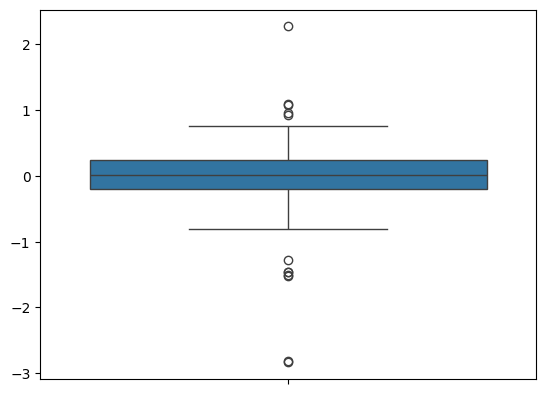

In [24]:
sns.boxplot(model1_weight_layer1)

<Axes: >

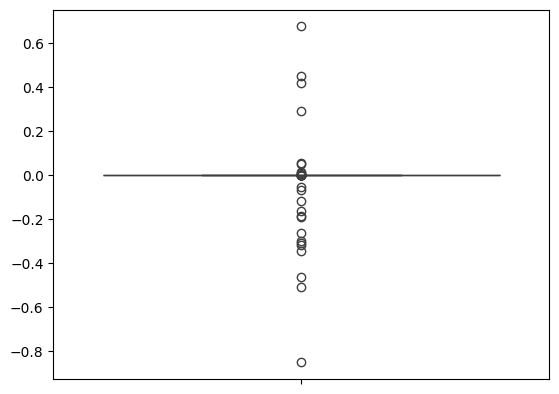

In [25]:
sns.boxplot(model2_weight_layer1)